<a href="https://colab.research.google.com/github/shoma1001/Summer_Training_2026_NIT_Patna/blob/main/DecisionTreeRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
#loading it directly
url="https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df=pd.read_csv(url)

In [ ]:
print(df.shape)
print(df.head())
print(df.describe())

(506, 14)
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.

In [ ]:
#checking for null values
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


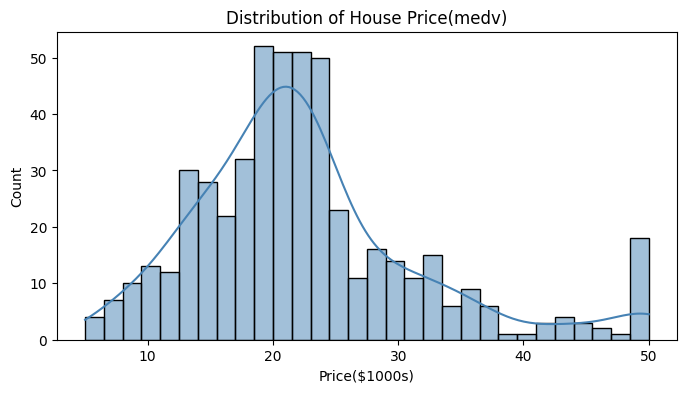

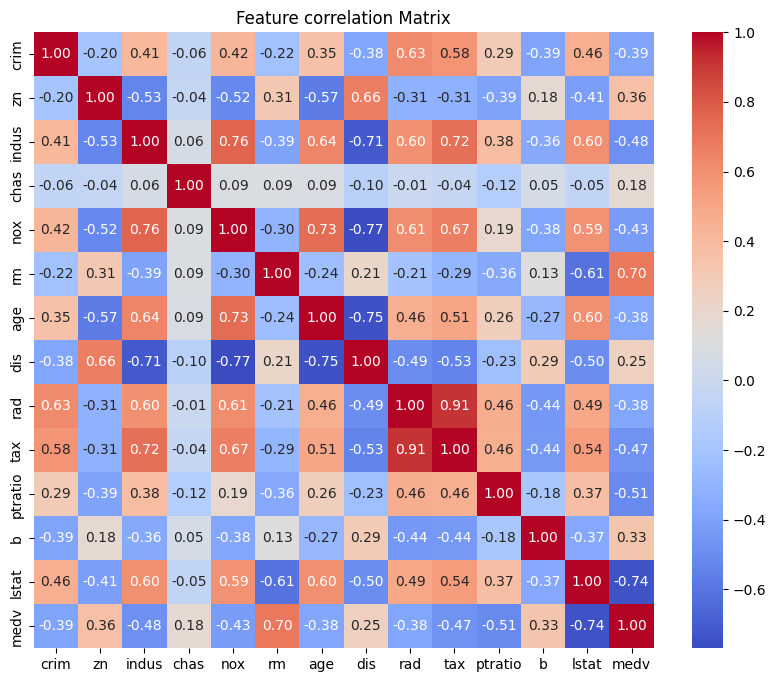

lstat     -0.737663
ptratio   -0.507787
indus     -0.483725
tax       -0.468536
nox       -0.427321
crim      -0.388305
rad       -0.381626
age       -0.376955
chas       0.175260
dis        0.249929
b          0.333461
zn         0.360445
rm         0.695360
medv       1.000000
Name: medv, dtype: float64


In [ ]:
#Target distribution
plt.figure(figsize=(8,4))
sns.histplot(df['medv'],bins=30,kde=True,color='steelblue')
plt.title('Distribution of House Price(medv)')
plt.xlabel('Price($1000s)')
plt.show()
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Feature correlation Matrix')
plt.show()
#most correlated feautures with target
print(df.corr()['medv'].sort_values())



In [ ]:
x= df.drop(['medv'],axis=1)
y=df['medv']
print('Feature shape:', x.shape)
print('Target shape:', y.shape)

Feature shape: (506, 13)
Target shape: (506,)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Train size: {x_train.shape[0]}")
print(f"Test size: {x_test.shape[0]}")

Train size: 404
Test size: 102


In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
dt_model= DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train,y_train)
#check tree size
print("Tree depth:", dt_model.get_depth())
print("No. of leaf nodes:", dt_model.get_n_leaves())

Tree depth: 19
No. of leaf nodes: 386


In [ ]:
# Predict on test set
y_pred = dt_model.predict(x_test)

In [ ]:
#Metrics
mse= mean_squared_error(y_test,y_pred)
mae= mean_absolute_error(y_test,y_pred)
r2= r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

MSE:  10.42
RMSE: 3.23
MAE:  2.39
R²:   0.8580


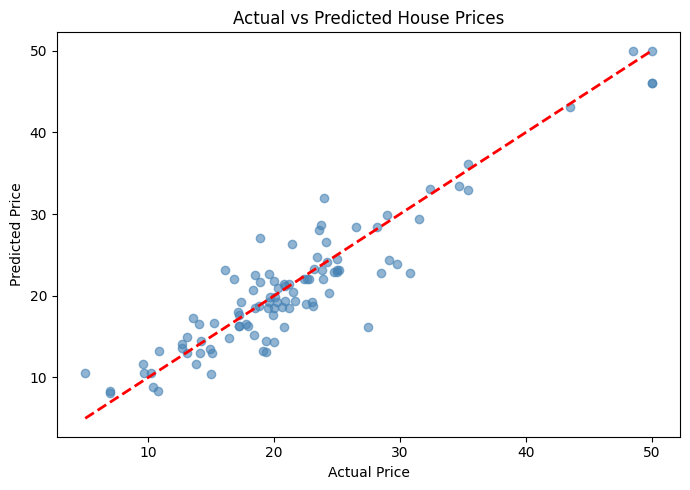

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

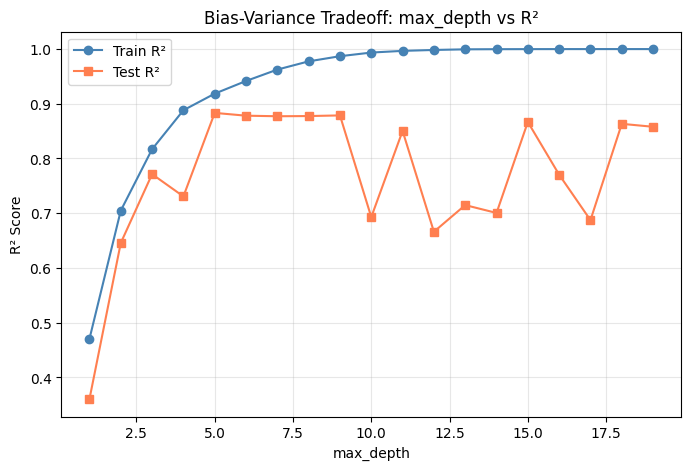

In [ ]:
train_scores, test_scores = [],[]
depths=range(1,20)
for d in depths:
  model=DecisionTreeRegressor(max_depth=d,random_state=42)
  model.fit(x_train,y_train)
  train_scores.append(r2_score(y_train,model.predict(x_train)))
  test_scores.append(r2_score(y_test,model.predict(x_test)))
#plot depth vs r2
plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, 'o-', label='Train R²', color='steelblue')
plt.plot(depths, test_scores, 's-', label='Test R²', color='coral')
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Bias-Variance Tradeoff: max_depth vs R²')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

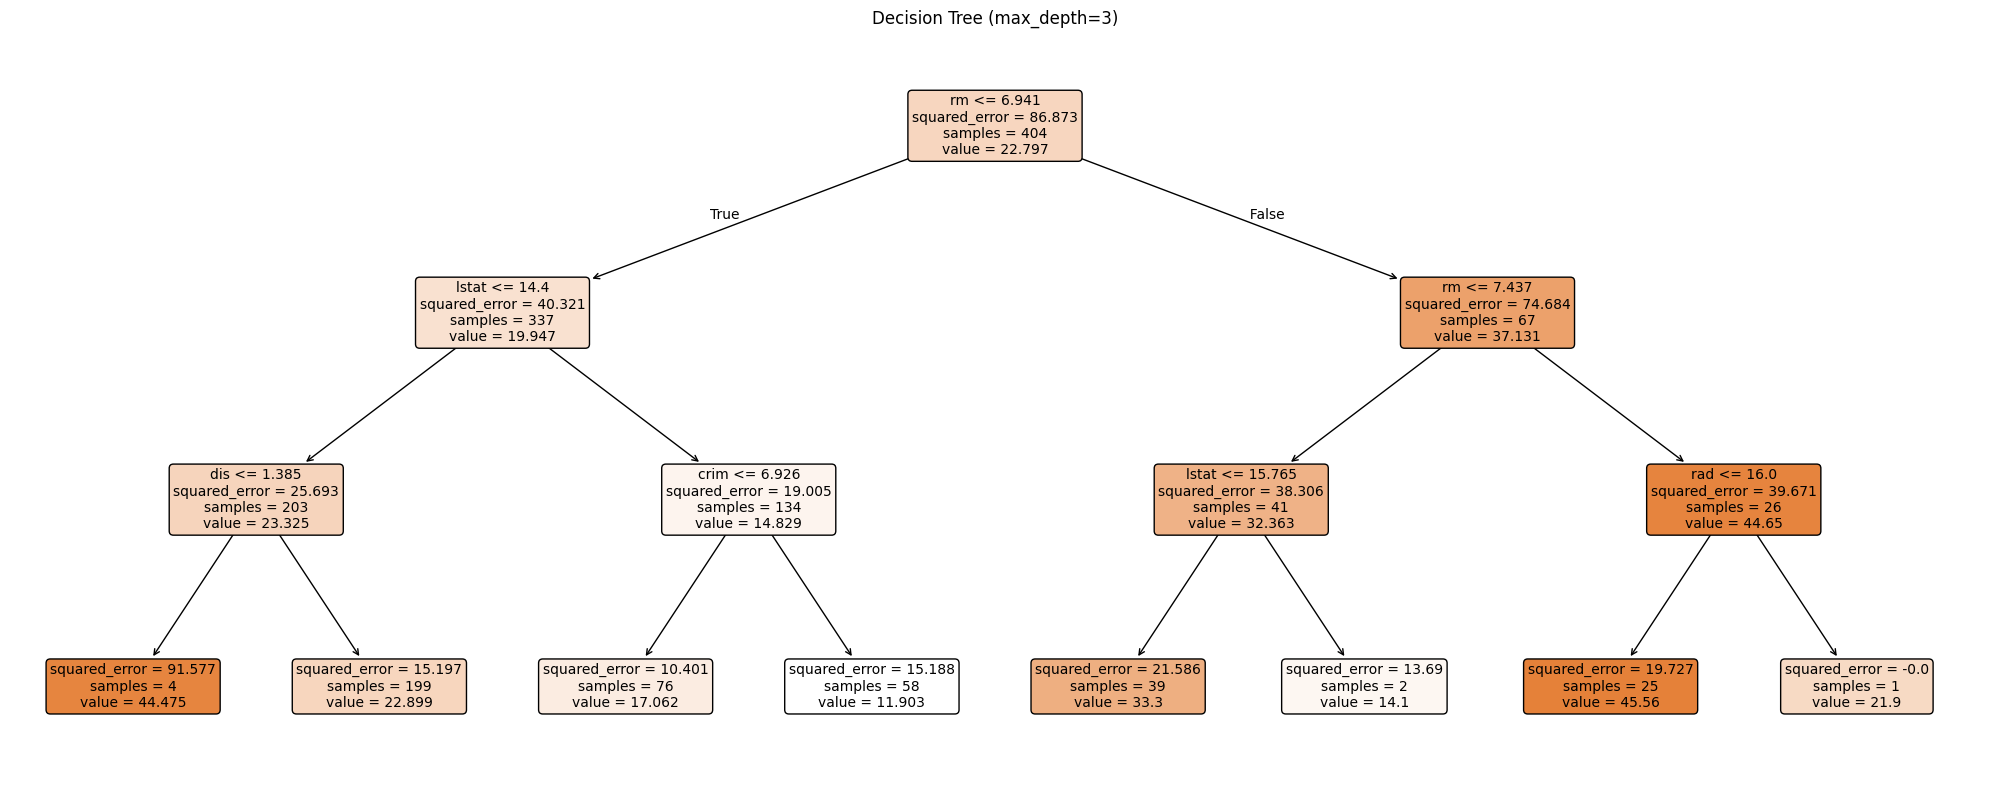

In [ ]:
# Train a shallow tree for readability
dt_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_viz.fit(x_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(
    dt_viz,
    feature_names=x.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.show()

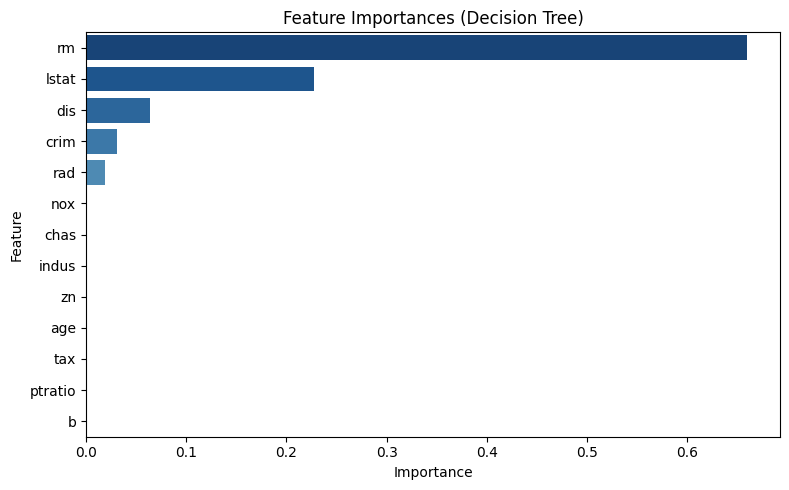

    Feature  Importance
5        rm    0.659397
12    lstat    0.227641
7       dis    0.063661
0      crim    0.030528
8       rad    0.018773
4       nox    0.000000
3      chas    0.000000
2     indus    0.000000
1        zn    0.000000
6       age    0.000000
9       tax    0.000000
10  ptratio    0.000000
11        b    0.000000


In [ ]:
importances = dt_viz.feature_importances_
feat_df = pd.DataFrame({ 'Feature': x.columns, 'Importance': importances }).sort_values('Importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Feature Importances (Decision Tree)')
plt.tight_layout()
plt.show()
print(feat_df)

In [ ]:
# Determine best_depth from previous analysis (cell q0PRpBhSTrWz)
best_depth_idx = np.argmax(test_scores)
best_depth = depths[best_depth_idx]
print(f"Optimal max_depth for the final model: {best_depth}")

# Final model with best depth
final_model = DecisionTreeRegressor( max_depth=best_depth, min_samples_split=10, min_samples_leaf=4, random_state=42 )

# 5-fold cross validation
cv_scores = cross_val_score(final_model, x, y, cv=5, scoring='r2' )
print(f"CV R² scores: {cv_scores.round(3)}")
print(f"Mean CV R²: {cv_scores.mean():.3f}")
print(f"Std CV R²: {cv_scores.std():.3f}")

# Train final model on all data
final_model.fit(x_train, y_train)
y_final_pred = final_model.predict(x_test)

print(f"\nFinal Test R²: {r2_score(y_test, y_final_pred):.4f}")
print(f"Final Test RMSE: {np.sqrt(mean_squared_error(y_test, y_final_pred)):.2f}")

Optimal max_depth for the final model: 5
CV R² scores: [0.647 0.799 0.685 0.426 0.018]
Mean CV R²: 0.515
Std CV R²: 0.277

Final Test R²: 0.8589
Final Test RMSE: 3.22
